In [1]:
from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
import load

Training trajectories shape: torch.Size([1000, 100, 24])
Training controls shape: torch.Size([1000, 99, 2])
Testing trajectories shape: torch.Size([215, 100, 24])
Testing controls shape: torch.Size([215, 99, 2])


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
trajectories_tensor_train = load.trajectories_tensor_train
controls_tensor_train = load.controls_tensor_train
trajectories_tensor_test = load.trajectories_tensor_test
controls_tensor_test = load.controls_tensor_test

In [5]:
batch_size = 32

torch_dataset_train = TensorDataset(trajectories_tensor_train)
torch_dataset_test = TensorDataset(trajectories_tensor_test)

train_dataloader = DataLoader(torch_dataset_train,
                              batch_size=batch_size,
                              shuffle=True)

test_dataloader = DataLoader(torch_dataset_test,
                             batch_size=batch_size,
                             shuffle=False)

In [6]:
(trajectory,) = next(iter(train_dataloader))

print("batch trajectory shape:", trajectory.shape)
print("one trajectory shape:", trajectory[0].shape)
print("one state shape:", trajectory[0, 0].shape)

batch trajectory shape: torch.Size([32, 100, 24])
one trajectory shape: torch.Size([100, 24])
one state shape: torch.Size([24])


In [7]:
feature_dim = 24      # dimension of the marker/state space
hidden_layers = 5     # number of hidden layers
latent_dim = 8        # Koopman latent dimension

In [8]:
class Encoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        layers = []
        for in_dim, out_dim in zip(layer_dims[:-2], layer_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())
        layers.append(nn.Linear(layer_dims[-2], layer_dims[-1]))

        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

In [9]:
class Decoder(nn.Module):
    def __init__(self, layer_dims: list[int]):
        super().__init__()

        reversed_dims = list(reversed(layer_dims))

        layers = []
        for in_dim, out_dim in zip(reversed_dims[:-2], reversed_dims[1:-1]):
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.ELU())

        layers.append(nn.Linear(reversed_dims[-2], reversed_dims[-1]))
        self.network = nn.Sequential(*layers)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.network(z)

In [10]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layers: int, latent_dim: int):
        super().__init__()

        layer_dims = [feature_dim + i * (latent_dim - feature_dim) // hidden_layers
            for i in range(hidden_layers)] + [latent_dim]

        self.encoder = Encoder(layer_dims)
        self.decoder = Decoder(layer_dims)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [11]:
autoencoder = Autoencoder(feature_dim, hidden_layers, latent_dim).to(device=device, dtype=torch.float64)

print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=24, out_features=20, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=20, out_features=17, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=17, out_features=14, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=14, out_features=11, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=11, out_features=8, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=8, out_features=11, bias=True)
      (1): ELU(alpha=1.0)
      (2): Linear(in_features=11, out_features=14, bias=True)
      (3): ELU(alpha=1.0)
      (4): Linear(in_features=14, out_features=17, bias=True)
      (5): ELU(alpha=1.0)
      (6): Linear(in_features=17, out_features=20, bias=True)
      (7): ELU(alpha=1.0)
      (8): Linear(in_features=20, out_features=24, bias=True)
    )
  )
)


In [12]:
def compute_K_DMD_from_trajectory(autoencoder, trajectory, m):
    """
    trajectory: tensor of shape [batch_size, T, feature_dim]
    m: number of time steps used to estimate K

    returns:
        K: tensor of shape [batch_size, latent_dim, latent_dim]
        z: tensor of shape [batch_size, T, latent_dim]
    """

    z = autoencoder.encoder(trajectory)    # [batch_size, T, latent_dim]

    z_data = z[:, :m, :]                # [batch_size, m, latent_dim]

    Z1 = z_data[:, :-1, :].transpose(1, 2)   # [batch_size, latent_dim, m-1]
    Z2 = z_data[:, 1:, :].transpose(1, 2)    # [batch_size, latent_dim, m-1]

    K = torch.matmul(Z2, torch.linalg.pinv(Z1)) # [batch_size, latent_dim, latent_dim]

    return K, z

In [13]:
(trajectory,) = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)

m = 50

K, z = compute_K_DMD_from_trajectory(autoencoder, trajectory, m)

print("trajectory shape:", trajectory.shape)
print("latent trajectory shape:", z.shape)
print("K shape:", K.shape)

trajectory shape: torch.Size([32, 100, 24])
latent trajectory shape: torch.Size([32, 100, 8])
K shape: torch.Size([32, 8, 8])


In [14]:
def rollout_with_K(K, z_start, pred_steps):
    """
    K: [batch_size, latent_dim, latent_dim]
    z_start: [batch_size, latent_dim]
    pred_steps: int

    returns:
        z_pred: [batch_size, pred_steps, latent_dim]
    """

    z_current = z_start
    z_preds = []

    for i in range(pred_steps):
        z_current = torch.bmm(K, z_current.unsqueeze(2)).squeeze(2) # [batch_size, latent_dim]
        z_preds.append(z_current)

    z_pred = torch.stack(z_preds, dim=1)   # [batch_size, pred_steps, latent_dim]

    return z_pred


In [15]:
z_start = z[:, m - 1, :]                          # [batch_size, latent_dim]
pred_steps = trajectory.shape[1] - m

z_pred = rollout_with_K(K, z_start, pred_steps)

print("z_start shape:", z_start.shape)
print("z_pred shape:", z_pred.shape)

z_start shape: torch.Size([32, 8])
z_pred shape: torch.Size([32, 50, 8])


In [16]:
mse_loss = nn.MSELoss()

def koopman_trajectory_loss(autoencoder, trajectory, m):
    """
    trajectory: [batch_size, T, feature_dim]
    m: number of steps used to estimate K

    returns:
        total_loss, loss_recon, loss_pred
    """

    z = autoencoder.encoder(trajectory)         # [bs, T, latent_dim]
    x_recon = autoencoder.decoder(z)            # [bs, T, feature_dim]

    loss_recon = mse_loss(x_recon[:, :m, :], trajectory[:, :m, :])

    z_history = z[:, :m, :]
    Z1 = z_history[:, :-1, :].transpose(1, 2)   # [bs, latent_dim, m-1]
    Z2 = z_history[:, 1:, :].transpose(1, 2)    # [bs, latent_dim, m-1]

    K = torch.matmul(Z2, torch.linalg.pinv(Z1)) # [bs, latent_dim, latent_dim]

    z_start = z[:, m - 1, :]                    # [bs, latent_dim]
    pred_steps = trajectory.shape[1] - m

    z_preds = []
    z_current = z_start

    for i in range(pred_steps):
        z_current = torch.bmm(K, z_current.unsqueeze(2)).squeeze(2)
        z_preds.append(z_current)

    z_pred = torch.stack(z_preds, dim=1)        # [bs, T-m, latent_dim]

    x_pred = autoencoder.decoder(z_pred)        # [bs, T-m, feature_dim]

    loss_pred = mse_loss(x_pred, trajectory[:, m:, :])

    loss = loss_recon + loss_pred

    return loss, loss_recon, loss_pred

In [17]:
(trajectory,) = next(iter(train_dataloader))
trajectory = trajectory.to(device=device, dtype=torch.float64)

m = 50

loss, loss_recon, loss_pred = koopman_trajectory_loss(autoencoder, trajectory, m)

print("total loss:", loss.item())
print("reconstruction loss:", loss_recon.item())
print("prediction loss:", loss_pred.item())

total loss: 0.5241680991868153
reconstruction loss: 0.31911047683412364
prediction loss: 0.20505762235269168


In [18]:
learning_rate = 1e-3
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

In [19]:
num_epochs = 200
m = 50

train_loss_history = []
train_recon_history = []
train_pred_history = []

test_loss_history = []
test_recon_history = []
test_pred_history = []

for epoch in range(num_epochs):
    autoencoder.train()

    train_loss_sum = 0.0
    train_recon_sum = 0.0
    train_pred_sum = 0.0
    train_batches = 0

    for (trajectory,) in train_dataloader:
        trajectory = trajectory.to(device=device, dtype=torch.float64)

        optimizer.zero_grad()

        loss, loss_recon, loss_pred = koopman_trajectory_loss(autoencoder, trajectory, m)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_recon_sum += loss_recon.item()
        train_pred_sum += loss_pred.item()
        train_batches += 1

    autoencoder.eval()

    test_loss_sum = 0.0
    test_recon_sum = 0.0
    test_pred_sum = 0.0
    test_batches = 0

    with torch.no_grad():
        for (trajectory,) in test_dataloader:
            trajectory = trajectory.to(device=device, dtype=torch.float64)

            loss, loss_recon, loss_pred = koopman_trajectory_loss(autoencoder, trajectory, m)

            test_loss_sum += loss.item()
            test_recon_sum += loss_recon.item()
            test_pred_sum += loss_pred.item()
            test_batches += 1

    train_loss_epoch = train_loss_sum / train_batches
    train_recon_epoch = train_recon_sum / train_batches
    train_pred_epoch = train_pred_sum / train_batches

    test_loss_epoch = test_loss_sum / test_batches
    test_recon_epoch = test_recon_sum / test_batches
    test_pred_epoch = test_pred_sum / test_batches

    train_loss_history.append(train_loss_epoch)
    train_recon_history.append(train_recon_epoch)
    train_pred_history.append(train_pred_epoch)

    test_loss_history.append(test_loss_epoch)
    test_recon_history.append(test_recon_epoch)
    test_pred_history.append(test_pred_epoch)

    print(
        f"Epoch {epoch + 1:03d} | "
        f"train loss: {train_loss_epoch:.6f} | "
        f"train recon: {train_recon_epoch:.6f} | "
        f"train pred: {train_pred_epoch:.6f} | "
        f"test loss: {test_loss_epoch:.6f} | "
        f"test recon: {test_recon_epoch:.6f} | "
        f"test pred: {test_pred_epoch:.6f}"
    )


Epoch 001 | train loss: 0.416000 | train recon: 0.256372 | train pred: 0.159628 | test loss: 0.325798 | test recon: 0.202715 | test pred: 0.123083
Epoch 002 | train loss: 0.275000 | train recon: 0.169055 | train pred: 0.105945 | test loss: 0.247887 | test recon: 0.152063 | test pred: 0.095824
Epoch 003 | train loss: 0.246408 | train recon: 0.149823 | train pred: 0.096584 | test loss: 0.246795 | test recon: 0.152218 | test pred: 0.094577
Epoch 004 | train loss: 0.245715 | train recon: 0.150711 | train pred: 0.095003 | test loss: 0.245360 | test recon: 0.151899 | test pred: 0.093461
Epoch 005 | train loss: 0.246396 | train recon: 0.151487 | train pred: 0.094910 | test loss: 0.244659 | test recon: 0.150942 | test pred: 0.093717
Epoch 006 | train loss: 0.244331 | train recon: 0.150077 | train pred: 0.094254 | test loss: 0.241616 | test recon: 0.149040 | test pred: 0.092576
Epoch 007 | train loss: 0.241182 | train recon: 0.147411 | train pred: 0.093771 | test loss: 0.236078 | test recon: 0.

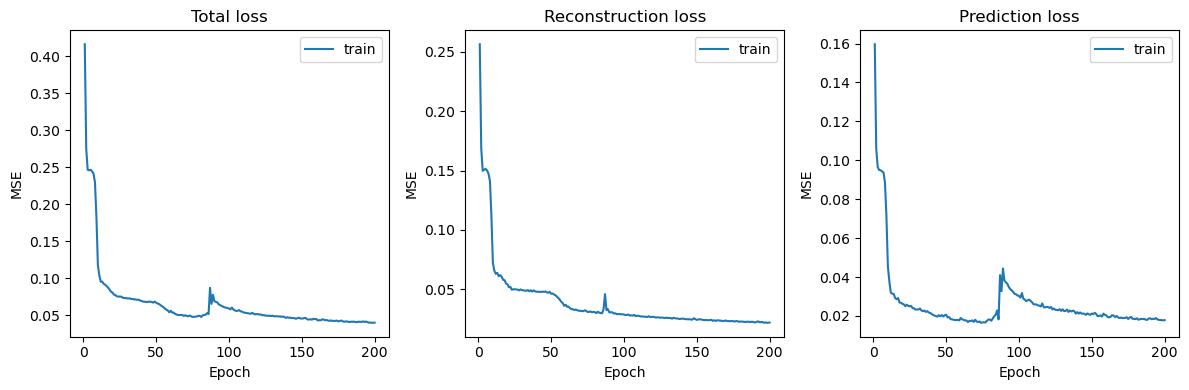

In [20]:
epochs = range(1, len(train_loss_history) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss_history, label="train")
#plt.plot(epochs, test_loss_history, label="test")
plt.title("Total loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, train_recon_history, label="train")
#plt.plot(epochs, test_recon_history, label="test")
plt.title("Reconstruction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, train_pred_history, label="train")
#plt.plot(epochs, test_pred_history, label="test")
plt.title("Prediction loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()

plt.tight_layout()
plt.show()

Trajectory: traj_1001
Original shape         : (100, 24)
Reconstructed shape    : (100, 24)
Predicted future shape : (50, 24)


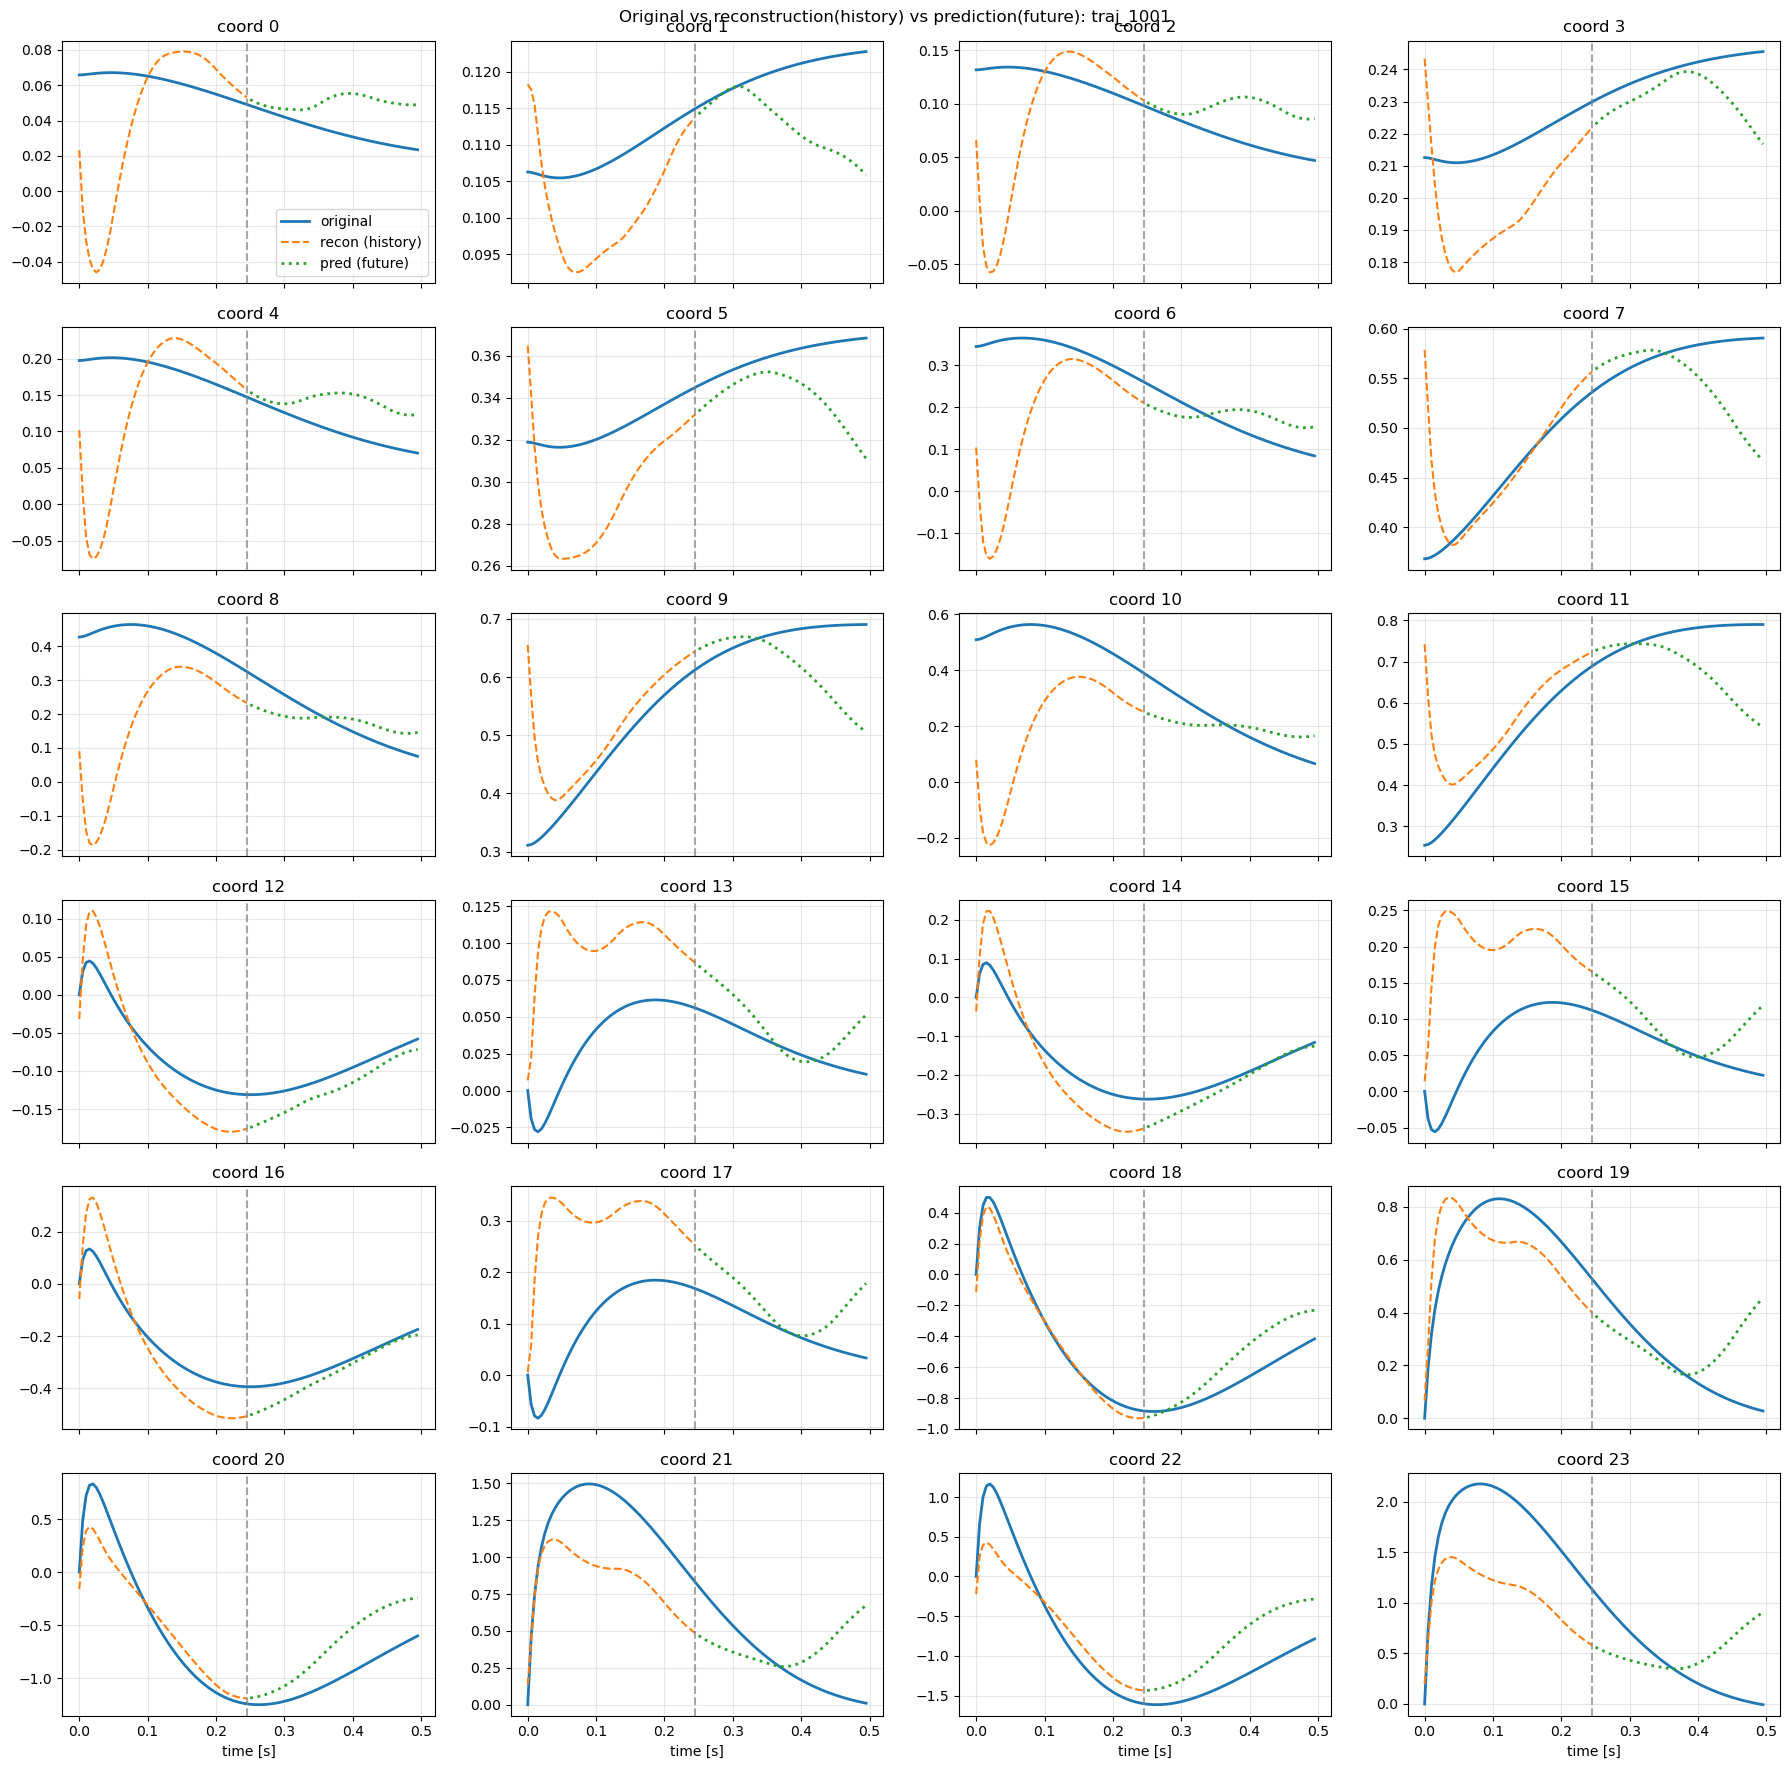

In [ ]:
from pathlib import Path
import numpy as np

root = Path.cwd().resolve().parents[1]
val_dir = root / "data" / "val"

traj_dir = sorted([p for p in val_dir.iterdir() if p.is_dir()])[0]

observations_np = np.load(traj_dir / "observations.npy")   # (24, 100)
controls_np = np.load(traj_dir / "controls.npy")           # (2, 99)

dt = 0.005
time = np.arange(observations_np.shape[1]) * dt

trajectory = torch.from_numpy(observations_np.T).to(torch.float64).unsqueeze(0)
trajectory = trajectory.to(device) if "device" in globals() else trajectory

m = 50

autoencoder.eval()
with torch.no_grad():
    K, z = compute_K_DMD_from_trajectory(autoencoder, trajectory, m)

    # reconstruction only on history
    x_recon = autoencoder.decoder(z)  # (1, T, 24)

    # prediction only on future
    z_start = z[:, m - 1, :]
    pred_steps = trajectory.shape[1] - m
    z_pred = rollout_with_K(K, z_start, pred_steps)
    x_pred_future = autoencoder.decoder(z_pred)  # (1, T-m, 24)

original = trajectory.squeeze(0).detach().cpu().numpy()          # (100, 24)
reconstructed = x_recon.squeeze(0).detach().cpu().numpy()        # (100, 24)
predicted_future = x_pred_future.squeeze(0).detach().cpu().numpy()  # (T-m, 24)

print("Trajectory:", traj_dir.name)
print("Original shape         :", original.shape)
print("Reconstructed shape    :", reconstructed.shape)
print("Predicted future shape :", predicted_future.shape)

fig, axes = plt.subplots(6, 4, figsize=(18, 18), sharex=True)
axes = axes.flatten()

for idx in range(24):
    ax = axes[idx]

    # original over all time
    ax.plot(time, original[:, idx], label="original", linewidth=2)

    # reconstruction only on observed/history part
    ax.plot(time[:m], reconstructed[:m, idx], "--", label="recon (history)", linewidth=1.5)

    # prediction only on future part
    ax.plot(time[m:], predicted_future[:, idx], ":", label="pred (future)", linewidth=2)

    ax.axvline(time[m - 1], color="gray", linestyle="--", alpha=0.7)
    ax.set_title(f"coord {idx}")
    ax.grid(True, alpha=0.3)

axes[0].legend(loc="best")
axes[-1].set_xlabel("time [s]")
axes[-2].set_xlabel("time [s]")
axes[-3].set_xlabel("time [s]")
axes[-4].set_xlabel("time [s]")

fig.suptitle(f"Original vs reconstruction(history) vs prediction(future): {traj_dir.name}")
fig.tight_layout()
plt.show()
